# ML

### Overall Strategy
We have 3 models: (1) AdaBoost, (2) Gradient Boost, and (3) Random Forest. We use a mix of Grid and Random Search for optimal parameteres and pair this with a 60-20-20 split for each model specification. 

Using the variety of parameters, we construct a normal approximation and evaluate whether or not the best model is statistically different from the average model (we also test a different random seed for the randomized search and compare the distributions to ensure that the randomness doesn't create statistical differences). We will then compare the models using McNemar's pairwise test and finally conduct some performance metrics on those models.

### Preliminaries

##### Packages

In [63]:
def warn(*args, **kwargs):
    pass
import warnings
warnings.warn = warn

import pandas as pd
import numpy as np
import random, time
from itertools import product
from operator import itemgetter
import matplotlib.pyplot as plt

from scipy.stats import norm
from statsmodels.stats.contingency_tables import mcnemar

from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import AdaBoostClassifier, GradientBoostingClassifier, RandomForestClassifier
from sklearn.metrics import confusion_matrix, roc_curve, roc_auc_score

random_seed = 123
random.seed(random_seed)
np.random.seed(random_seed)

##### Printing Objects

In [5]:
def stringify(res): # Takes in a result object of { 'score': int, ['options': values] }
    iterated_keys = list(set(res.keys()) - set(['score']))
    specs_string = f'({', '.join([str(res[x]) for x in iterated_keys])})'
    return f'{specs_string}; score: {round(res['score'], 3)}'

### Dataset

In [6]:
df = pd.read_csv('hie_dataset.csv')
df

,country,year,"GNI per capita, Atlas method (current US$)","Population, total",Surface area (sq. km),Population living in slums (% of urban population),hie,near_2_plus_oceans,border_count,size
0,Albania,2000,1130.0,3089027.0,28750.0,28.10000,False,False,4.0,small
1,Angola,2000,360.0,16194869.0,1246700.0,19.70000,False,False,4.0,large
2,Argentina,2000,7400.0,37213984.0,2780400.0,20.29188,False,True,5.0,large
3,Armenia,2000,630.0,3221100.0,29740.0,12.79599,False,False,4.0,small
4,Aruba,2000,20060.0,90588.0,180.0,0.00000,True,False,0.0,small
...,...,...,...,...,...,...,...,...,...,...
1897,Vanuatu,2022,3830.0,313046.0,12190.0,3.06400,False,False,0.0,small
1898,Venezuela,2022,2260.0,28213017.0,912050.0,25.70000,False,False,3.0,medium
1899,Vietnam,2022,3980.0,99680655.0,331340.0,32.50000,False,False,3.0,large
1900,Zambia,2022,1170.0,20152938.0,752610.0,48.25813,False,False,8.0,medium


##### Generating Confidence Interval Graph

In [7]:
def gen_CI(mean, std):
    ax = np.arange(mean - 4 * std, mean + 4 * std, 0.0001)
    plt.plot(ax, norm.pdf(ax, mean, std))
    plt.axvline(mean, 0, 0.95, linestyle = 'dashed')
    # plt.axhline(1, mean - 2 * std, mean - std)
    plt.text(mean + 0.003, 0, f'mu = {round(mean, 3)}', rotation = 0)
    plt.text(mean + 2 * std, 3, f'sigma = {round(std, 3)}', rotation = 0)

    x_CIs = []
    for alpha in [0.9, 0.95, 0.99]:
        x_CIs.extend(norm.interval(alpha, loc = mean, scale = std))
    x_CIs = np.array(x_CIs)
    y_points = np.array([0] * 6)
    plt.plot(x_CIs, y_points, 'o')
    plt.show()

### Data
60, 20, 20 split

In [64]:
x_overall = df[['year', "Population living in slums (% of urban population)", 'near_2_plus_oceans', 'border_count', 'size']]
y = df[['hie']]
one_hot = pd.get_dummies(x_overall['size'])
x_overall = x_overall.drop('size', axis = 1)
x_overall = x_overall.join(one_hot)
X_train, X_test_val, y_train, y_test_val = train_test_split(x_overall, y, test_size = 0.4, random_state = random_seed)
X_test, X_valid, y_test, y_valid = train_test_split(X_test_val, y_test_val, test_size = 0.5, random_state = random_seed)

### AdaBoosting

Best Valid.: (gini, 7, 1.0924148692924316); score: 0.948
Final: (gini, 7, 1.0924148692924316); score: 0.947; Models Trained: 64
MU = 0.9345472440944881, SIGMA = 0.0073343467539724915
Standard Deviations from Mean = 1.6978684432621216, p-value = 0.044766297207932064


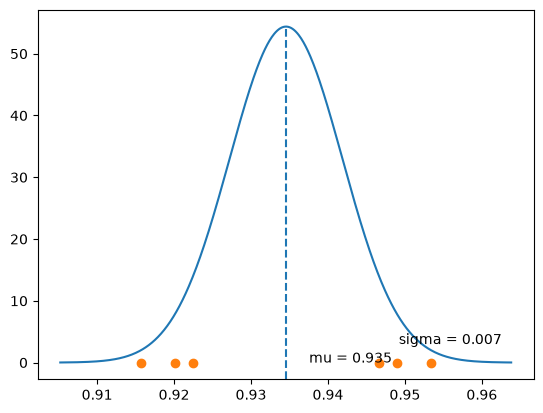

In [65]:
np.random.seed(random_seed)
# Grid / Random Search Options
options = { 'criterion': ['gini', 'entropy'], 'max-depth': [1, 3, 5, 7], 'learning-rate': np.random.rand(8) * 0.5 + 0.75 }
keys, values = zip(*options.items())
option_combos = [dict(zip(keys, p)) for p in product(*values)]

# Training Models
results = []
for combo in option_combos:
    # Training
    estimator = DecisionTreeClassifier(criterion = combo['criterion'], max_depth = combo['max-depth'], random_state = random_seed)
    clf = AdaBoostClassifier(estimator = estimator, n_estimators = 100, random_state = random_seed, learning_rate = combo['learning-rate'])
    clf.fit(X_train, y_train.values.ravel())
    
    # Cross Validation (Holdout)
    score = clf.score(X_valid, y_valid)
    res = { 'score': score, 'criterion': combo['criterion'], 'max-depth': combo['max-depth'], 'learning-rate': combo['learning-rate'] }
    results.append(res)

# Training the Best Model and Testing
sorted_results = sorted(results, key = lambda d: d['score'], reverse = True)
print(f'Best Valid.: {stringify(sorted_results[0])}')
final_estimator = DecisionTreeClassifier(criterion = sorted_results[0]['criterion'], max_depth = sorted_results[0]['max-depth'], random_state = random_seed)
final_adaboost = AdaBoostClassifier(estimator = estimator, n_estimators = 100, random_state = random_seed, learning_rate = sorted_results[0]['learning-rate'])
final_adaboost.fit(pd.concat([X_train, X_valid]), pd.concat([y_train, y_valid]).values.ravel())
final_score = final_adaboost.score(X_test, y_test) # type: ignore
final_res = { 'score': round(final_score, 3), 'criterion': sorted_results[0]['criterion'], 'max-depth': sorted_results[0]['max-depth'], 'learning-rate': sorted_results[0]['learning-rate'] }
print(f'Final: {stringify(final_res)}; Models Trained: {len(options['criterion']) * len(options['max-depth']) * len(options['learning-rate'])}')

# Normal Approximation and Hypothesis Testing
scores = np.array([d['score'] for d in results])
print(f'MU = {scores.mean()}, SIGMA = {scores.std()}')

stds_away = (final_res['score'] - scores.mean()) / scores.std()
p_value = norm.sf(abs(stds_away)) # a one-sided stat was used because we know that this value will be above the mean.
print(f'Standard Deviations from Mean = {stds_away}, p-value = {p_value}')

gen_CI(scores.mean(), scores.std())

### Gradient Boosting

Best Valid.: (exponential, 7, 0.19711462975769234); score: 0.945
Final: (exponential, 7, 0.19711462975769234); score: 0.953; Models Trained: 64
MU = 0.9330625, SIGMA = 0.00694144032244026
Standard Deviations from Mean = 2.8722425136388585, p-value = 0.002037850315901044


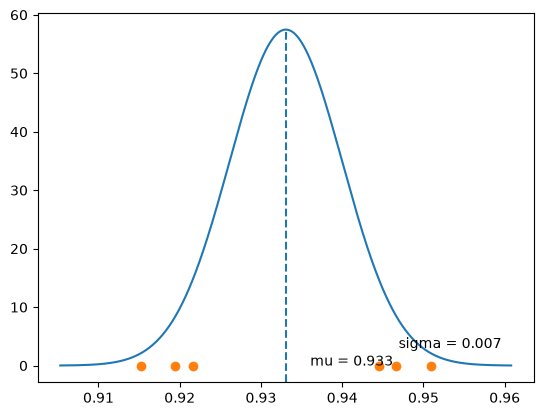

In [66]:
np.random.seed(random_seed)
# Grid / Random Search Options
options = { 'loss': ['log_loss', 'exponential'], 'learning-rate': np.random.rand(8) * 0.15 + 0.05, 'max-depth': [1, 3, 5, 7] }
keys, values = zip(*options.items())
option_combos = [dict(zip(keys, p)) for p in product(*values)]

# Training Models
results = []
for combo in option_combos:
    # Training
    clf = GradientBoostingClassifier(loss = combo['loss'], learning_rate = combo['learning-rate'], max_depth = combo['max-depth'], random_state = random_seed)
    clf.fit(X_train, y_train.values.ravel())
    
    # Cross Validation (Holdout)
    score = clf.score(X_valid, y_valid)
    res = { 'score': round(score, 3), 'loss': combo['loss'], 'max-depth': combo['max-depth'], 'learning-rate': combo['learning-rate'] }
    results.append(res)

# Training the Best Model and Testing
sorted_results = sorted(results, key = lambda d: d['score'], reverse = True)
print(f'Best Valid.: {stringify(sorted_results[0])}')
final_gradientboost = GradientBoostingClassifier(loss = sorted_results[0]['loss'], learning_rate = sorted_results[0]['learning-rate'], max_depth = sorted_results[0]['max-depth'], random_state = random_seed)
final_gradientboost.fit(pd.concat([X_train, X_valid]), pd.concat([y_train, y_valid]).values.ravel())
final_score = final_gradientboost.score(X_test, y_test) # type: ignore
final_res = { 'score': round(final_score, 3), 'loss': sorted_results[0]['loss'], 'max-depth': sorted_results[0]['max-depth'], 'learning-rate': sorted_results[0]['learning-rate'] }
print(f'Final: {stringify(final_res)}; Models Trained: {len(options['loss']) * len(options['max-depth']) * len(options['learning-rate'])}')

# Normal Approximation and Hypothesis Testing
scores = np.array([d['score'] for d in results])
print(f'MU = {scores.mean()}, SIGMA = {scores.std()}')

stds_away = (final_res['score'] - scores.mean()) / scores.std()
p_value = norm.sf(abs(stds_away)) # a one-sided stat was used because we know that this value will be above the mean.
print(f'Standard Deviations from Mean = {stds_away}, p-value = {p_value}')

gen_CI(scores.mean(), scores.std())

### Random Forest

Best Valid.: (gini, 6, None); score: 0.94
Final: (gini, 6, None); score: 0.937; Models Trained: 36
MU = 0.923777777777778, SIGMA = 0.005977323402805671
Standard Deviations from Mean = 2.21206405128016, p-value = 0.01348111979105276


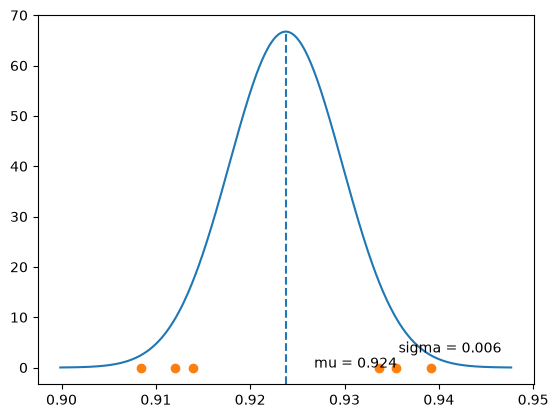

In [67]:
# Grid / Random Search Options
options = { 'criterion': ['gini', 'entropy', 'log_loss'], 'max-depth': [2, 4, 6, 8], 'max-features': ['sqrt', 'log2', None] }
keys, values = zip(*options.items())
option_combos = [dict(zip(keys, p)) for p in product(*values)]

# Training Models
results = []
for combo in option_combos:
    # Training
    clf = RandomForestClassifier(criterion = combo['criterion'], max_depth = combo['max-depth'], max_features = combo['max-features'], random_state = random_seed)
    clf.fit(X_train, y_train.values.ravel())
    
    # Cross Validation (Holdout)
    score = clf.score(X_valid, y_valid)
    res = { 'score': round(score, 3), 'criterion': combo['criterion'], 'max-depth': combo['max-depth'], 'max-features': combo['max-features'] }
    results.append(res)

# Training the Best Model and Testing
sorted_results = sorted(results, key = lambda d: d['score'], reverse = True)
print(f'Best Valid.: {stringify(sorted_results[0])}')
final_randomforest = RandomForestClassifier(criterion = sorted_results[0]['criterion'], max_depth = sorted_results[0]['max-depth'], max_features = sorted_results[0]['max-features'], random_state = random_seed)
final_randomforest.fit(pd.concat([X_train, X_valid]), pd.concat([y_train, y_valid]).values.ravel())
final_score = final_randomforest.score(X_test, y_test) # type: ignore
final_res = { 'score': round(final_score, 3), 'criterion': sorted_results[0]['criterion'], 'max-depth': sorted_results[0]['max-depth'], 'max_features': sorted_results[0]['max-features'] }
print(f'Final: {stringify(final_res)}; Models Trained: {len(options['criterion']) * len(options['max-depth']) * len(options['max-features'])}')

# Normal Approximation and Hypothesis Testing
scores = np.array([d['score'] for d in results])
print(f'MU = {scores.mean()}, SIGMA = {scores.std()}')

stds_away = (final_res['score'] - scores.mean()) / scores.std()
p_value = norm.sf(abs(stds_away)) # a one-sided stat was used because we know that this value will be above the mean.
print(f'Standard Deviations from Mean = {stds_away}, p-value = {p_value}')

gen_CI(scores.mean(), scores.std())

### Testing

##### McNemar's Pairwise Test to Compare Models

In [68]:
adaboost_predict = final_adaboost.predict(X_test)
gradientboost_predict = final_gradientboost.predict(X_test)
randomforest_predict = final_randomforest.predict(X_test)

adaboost_gradientboost_confusion_matrix = confusion_matrix(adaboost_predict, gradientboost_predict)
adaboost_randomforest_confusion_matrix = confusion_matrix(adaboost_predict, randomforest_predict)
gradientboost_randomforest_confusion_matrix = confusion_matrix(gradientboost_predict, randomforest_predict)

print("Ada Boost vs. Gradient Boost")
print(mcnemar(adaboost_gradientboost_confusion_matrix, exact = True, correction = True))

print("\nAda Boost vs. Random Forest")
print(mcnemar(adaboost_randomforest_confusion_matrix, exact = True, correction = True))

print("\nGradient Boost vs. Random Forest")
print(mcnemar(gradientboost_randomforest_confusion_matrix, exact = True, correction = True))

Ada Boost vs. Gradient Boost
pvalue      0.6875
statistic   2.0

Ada Boost vs. Random Forest
pvalue      1.049041748046875e-05
statistic   2.0

Gradient Boost vs. Random Forest
pvalue      8.797645568847656e-05
statistic   3.0


We can conclude that the Ada and Gradient Boost models are statistically the same while the Random Forest is worse.

##### Performance Metrics

Get Precision, Recall, and F1 score

In [69]:
def get_precision_recall_f1(conf_mat):
    precision = conf_mat[0, 0] / (conf_mat[0, 0] + conf_mat[1, 0])
    recall = conf_mat[0, 0] / (conf_mat[0, 0] + conf_mat[0, 1])

    return (precision, recall, (2 * precision * recall) / (precision + recall))

In [71]:
adaboost_confusion_matrix = confusion_matrix(adaboost_predict, y_test)
gradientboost_confusion_matrix = confusion_matrix(gradientboost_predict, y_test)

for model_matrix in [('Ada Boost', adaboost_confusion_matrix), ('Gradient Boost', gradientboost_confusion_matrix)]:
    precision_recall_f1 = get_precision_recall_f1(model_matrix[1])
    print(f'{model_matrix[0]}: \n - Precision: {round(precision_recall_f1[0], 4)}\n - Recall: {round(precision_recall_f1[1], 4)}\n - F1: {round(precision_recall_f1[2], 4)}\n')

Ada Boost: 
 - Precision: 0.9531
 - Recall: 0.9742
 - F1: 0.9635

Gradient Boost: 
 - Precision: 0.9603
 - Recall: 0.9744
 - F1: 0.9673



### Robustness Checks
The robustness check is to see if the random seed is not relevant by redoing the model training with different seeds and comparing the distributions with ANOVA.